# OLS Instability Under Multicollinearity and How Ridge Fixes It

## Motivation

Ordinary Least Squares (OLS) is the foundation of linear regression.
Its analytical estimator gives us the exact optimal coefficients:

$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

But this formula has a hidden weakness: when two or more explanatory
variables are highly correlated (**multicollinearity**), the matrix
$X^\top X$ becomes nearly singular and its inversion becomes
numerically unstable.

The consequences are severe:
- Estimated coefficients $\hat{\beta}$ explode to extreme values
- Small changes in the data cause huge changes in the coefficients
- The model becomes unreliable despite a good R²

## What This Notebook Demonstrates

We will **prove** this instability mathematically and visually by:

1. Generating synthetic data with controlled correlation $\rho$ between two variables
2. Showing how OLS coefficients diverge from the true values as $\rho \to 1$
3. Measuring instability via the **condition number** of $X^\top X$
4. Introducing Ridge regression as a solution and analyzing how its
   hyperparameter $\lambda$ controls the bias-variance tradeoff
5. Selecting $\lambda$ visually via the **ridge trace**
6. Quantifying the gain: comparing OLS and Ridge prediction error (MSE)

> Since we use synthetic data, we know the **true coefficients** exactly.
> This lets us measure OLS error precisely, something impossible on real data.

In [2]:
# Standard scientific stack
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

## 1. Generating Synthetic Data

We generate a dataset where we control the correlation $\rho$ between
two explanatory variables $X_1$ and $X_2$.

The true underlying model is:

$$y = 2X_1 + 3X_2 + \epsilon \quad \text{with} \quad \epsilon \sim \mathcal{N}(0, 0.5)$$

The true coefficients are therefore $\beta_1 = 2$ and $\beta_2 = 3$.
By construction, we know the ground truth, which allows us to measure
OLS estimation error precisely.

The covariance structure of $(X_1, X_2)$ is:

$$\Sigma = \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}$$

When $\rho = 0$, the variables are independent. As $\rho \to 1$,
multicollinearity increases and OLS becomes unstable.

In [3]:
def generate_data(rho, n=200, seed=42):
    """
    Generate a synthetic dataset with two correlated explanatory variables.

    Parameters
    ----------
    rho  : float, correlation between X1 and X2 (between 0 and 1)
    n    : int, number of observations
    seed : int, random seed for reproducibility

    Returns
    -------
    X         : array of shape (n, 2), explanatory variables
    y         : array of shape (n,), target variable
    beta_true : array of shape (2,), true coefficients
    """
    rng = np.random.default_rng(seed)

    # Covariance matrix controlled by rho
    cov = [[1, rho],
           [rho, 1]]

    # Draw correlated variables
    X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n)

    # True coefficients
    beta_true = np.array([2.0, 3.0])

    # Target with Gaussian noise
    y = X @ beta_true + rng.normal(0, 0.5, size=n)

    return X, y, beta_true

In [4]:
X, y, beta_true = generate_data(rho=0.0)
print("X shape :", X.shape)
print("y shape :", y.shape)
print("True coefficients :", beta_true)
print("Correlation between X1 and X2 :", np.corrcoef(X[:, 0], X[:, 1])[0, 1].round(3))

X shape : (200, 2)
y shape : (200,)
True coefficients : [2. 3.]
Correlation between X1 and X2 : 0.06


## 2. OLS From Scratch

The OLS analytical estimator is:

$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

We implement it using NumPy only, without any machine learning library.
Note that we add a column of ones to $X$ to account for the intercept
$\beta_0$.

In [5]:
def ols(X, y):
    """
    Compute OLS coefficients using the analytical estimator.

    Parameters
    ----------
    X : array of shape (n, p), explanatory variables
    y : array of shape (n,), target variable

    Returns
    -------
    beta : array of shape (p+1,), estimated coefficients (intercept first)
    """
    # Add a column of ones for the intercept
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])

    # Analytical estimator : beta = (X'X)^-1 X'y
    beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

    return beta

In [6]:
X, y, beta_true = generate_data(rho=0.0)
beta_ols = ols(X, y)

print("True coefficients    :", beta_true)
print("OLS  (intercept, b1, b2) :", beta_ols.round(3))

True coefficients    : [2. 3.]
OLS  (intercept, b1, b2) : [-0.035  1.991  2.973]


## 3. The Multicollinearity Problem

We now vary $\rho$ from 0 to 0.99 and observe how OLS coefficients
behave as the two variables become increasingly correlated.

To measure instability mathematically, we use the **condition number**
of $X^\top X$, defined as:

$$\kappa(X^\top X) = \frac{\lambda_{max}}{\lambda_{min}}$$

Where $\lambda_{max}$ and $\lambda_{min}$ are the largest and smallest
eigenvalues of $X^\top X$.

Intuitively:
- $\kappa \approx 1$ : the matrix is well conditioned, inversion is stable
- $\kappa \gg 1$ : the matrix is nearly singular, inversion is unstable
- $\kappa \to \infty$ : the matrix is singular, inversion is impossible

A condition number above 30 is generally considered a signal of
serious multicollinearity.

In [7]:
# Range of correlation values to test
rho_values = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99, 0.995, 0.999, 0.9999]

# Store results
results = []

for rho in rho_values:
    X, y, beta_true = generate_data(rho=rho)

    # Add intercept column
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])

    # Compute condition number of X'X
    XtX = X_b.T @ X_b
    eigenvalues = np.linalg.eigvalsh(XtX)
    condition_number = eigenvalues.max() / eigenvalues.min()

    # Fit OLS
    beta_ols = ols(X, y)

    results.append({
        "rho" : rho,
        "condition_number" : condition_number,
        "beta1_ols" : beta_ols[1],
        "beta2_ols" : beta_ols[2],
        "beta1_error" : abs(beta_ols[1] - beta_true[0]),
        "beta2_error" : abs(beta_ols[2] - beta_true[1]),
    })

# Display results
import pandas as pd
df = pd.DataFrame(results)
df.round(3)

,rho,condition_number,beta1_ols,beta2_ols,beta1_error,beta2_error
0,0.000,1.250,1.991,2.973,0.009,0.027
1,0.300,2.193,2.028,2.983,0.028,0.017
2,0.500,3.525,2.032,2.978,0.032,0.022
3,0.700,6.643,2.039,2.970,0.039,0.030
4,0.800,10.543,2.047,2.963,0.047,0.037
5,0.900,22.243,2.064,2.945,0.064,0.055
6,0.950,45.644,2.089,2.920,0.089,0.080
7,0.970,76.845,2.113,2.896,0.113,0.104
8,0.990,232.853,2.193,2.816,0.193,0.184
9,0.995,466.864,2.271,2.738,0.271,0.262


## 4. Visualizing OLS Instability

The table above shows the numerical evidence. We now plot the results
to make the instability visually clear.

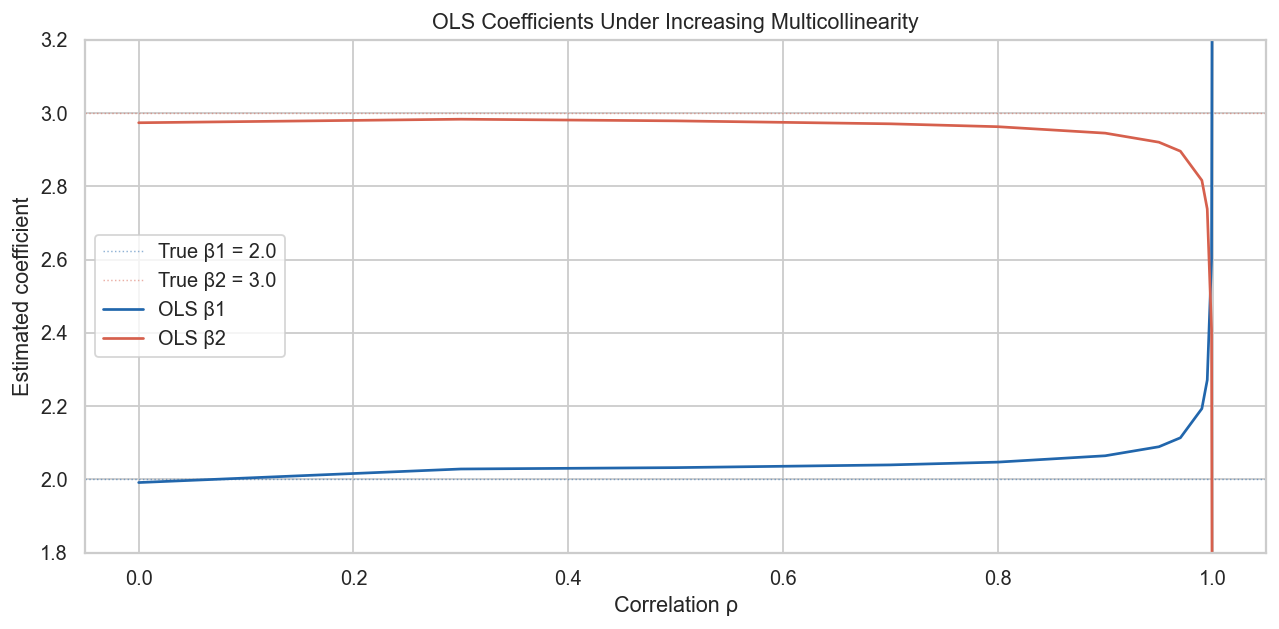

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(y=2.0, color="#2166ac", linestyle=":", linewidth=0.8, alpha=0.5, label="True β1 = 2.0")
ax.axhline(y=3.0, color="#d6604d", linestyle=":", linewidth=0.8, alpha=0.5, label="True β2 = 3.0")

ax.plot(df["rho"], df["beta1_ols"], "-", color="#2166ac", linewidth=1.5, label="OLS β1")
ax.plot(df["rho"], df["beta2_ols"], "-", color="#d6604d", linewidth=1.5, label="OLS β2")

ax.set_ylim(1.8, 3.2)
ax.set_xlabel("Correlation ρ")
ax.set_ylabel("Estimated coefficient")
ax.set_title("OLS Coefficients Under Increasing Multicollinearity")
ax.legend()

plt.tight_layout()
plt.savefig("images/ols_instability_coeffs.png", dpi=130, bbox_inches="tight")
plt.show()

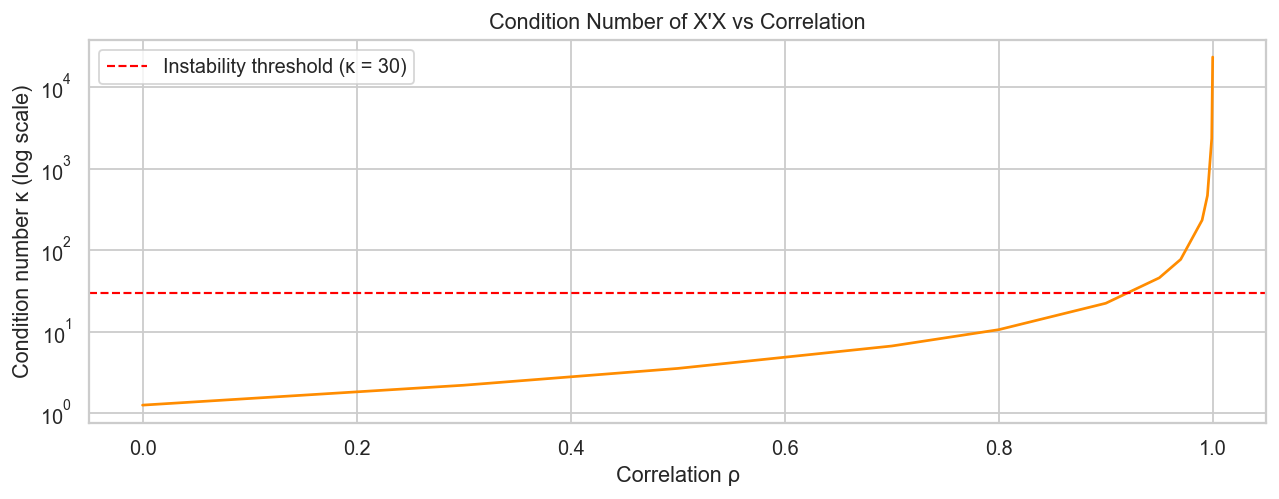

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["rho"], df["condition_number"], "-", color="darkorange", linewidth=1.5)
ax.axhline(y=30, color="red", linestyle="--", linewidth=1.2, label="Instability threshold (κ = 30)")
ax.set_yscale("log")
ax.set_xlabel("Correlation ρ")
ax.set_ylabel("Condition number κ (log scale)")
ax.set_title("Condition Number of X'X vs Correlation")
ax.legend()

plt.tight_layout()
plt.savefig("images/condition_number.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Ridge Regression as a Solution

Ridge regression modifies the OLS estimator by adding a regularization
term $\lambda I$ to $X^\top X$ before inversion:

$$\hat{\beta}_{Ridge} = (X^\top X + \lambda I)^{-1} X^\top y$$

This small addition has a crucial effect: it guarantees that the matrix
is always invertible, regardless of multicollinearity. The eigenvalues
of $X^\top X + \lambda I$ are all shifted by $\lambda$, which prevents
them from reaching zero.

We will now run the same experiment with Ridge and compare the results.

In [10]:
def ridge(X, y, lam=0.1):
    """
    Compute Ridge coefficients using the analytical estimator.

    Parameters
    ----------
    X   : array of shape (n, p), explanatory variables
    y   : array of shape (n,), target variable
    lam : float, regularization strength (lambda)

    Returns
    -------
    beta : array of shape (p+1,), estimated coefficients (intercept first)
    """
    # Add a column of ones for the intercept
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])

    # Identity matrix - we do not penalize the intercept
    I = np.eye(X_b.shape[1])
    I[0, 0] = 0

    # Analytical estimator : beta = (X'X + lambda*I)^-1 X'y
    beta = np.linalg.inv(X_b.T @ X_b + lam * I) @ X_b.T @ y

    return beta

In [13]:
X, y, beta_true = generate_data(rho=0.999)
beta_ols   = ols(X, y)
beta_ridge = ridge(X, y, lam=0.5)

print("True coefficients :", beta_true)
print("OLS               :", beta_ols[1:].round(3))
print("Ridge             :", beta_ridge[1:].round(3))

True coefficients : [2. 3.]
OLS               : [2.6   2.408]
Ridge             : [2.528 2.475]


In [19]:
results_ridge = []

for rho in rho_values:
    X, y, beta_true = generate_data(rho=rho)

    beta_ols   = ols(X, y)
    beta_ridge = ridge(X, y, lam=0.5)

    results_ridge.append({
        "rho"          : rho,
        "beta1_ols"    : beta_ols[1],
        "beta2_ols"    : beta_ols[2],
        "beta1_ridge"  : beta_ridge[1],
        "beta2_ridge"  : beta_ridge[2],
    })

df_ridge = pd.DataFrame(results_ridge)

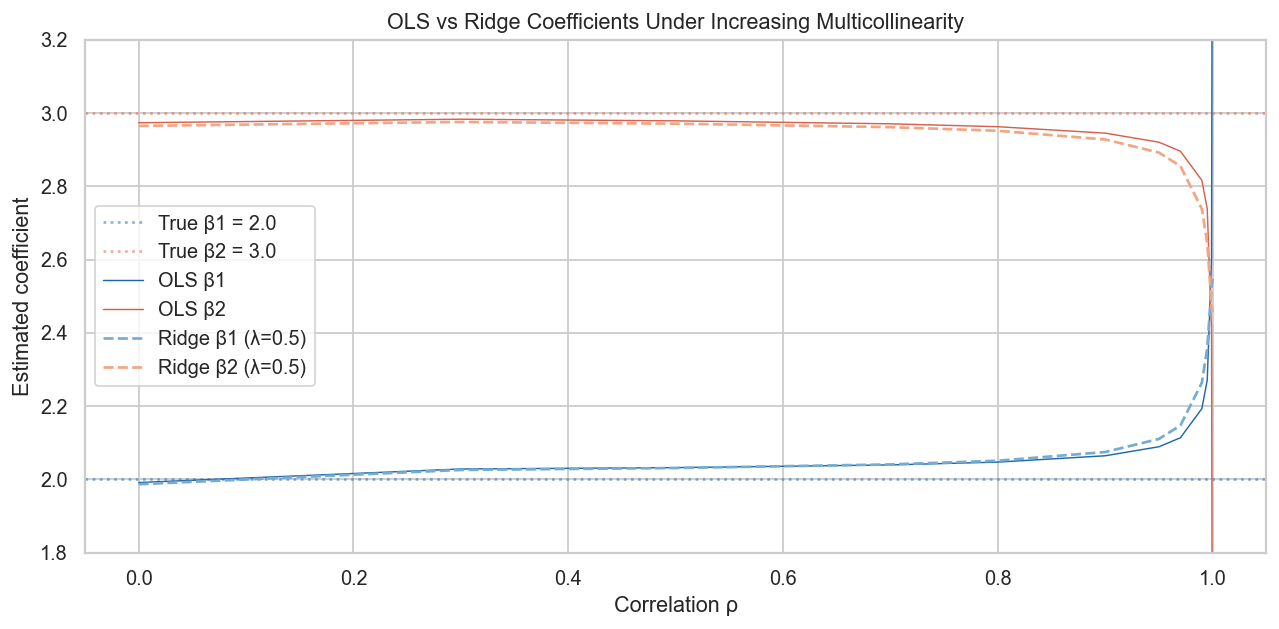

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(y=2.0, color="#2166ac", linestyle=":", alpha=0.5, label="True β1 = 2.0")
ax.axhline(y=3.0, color="#d6604d", linestyle=":", alpha=0.5, label="True β2 = 3.0")

ax.plot(df_ridge["rho"], df_ridge["beta1_ols"],   "-",  color="#2166ac", linewidth=0.8, label="OLS β1")
ax.plot(df_ridge["rho"], df_ridge["beta2_ols"],   "-",  color="#d6604d", linewidth=0.8, label="OLS β2")
ax.plot(df_ridge["rho"], df_ridge["beta1_ridge"], "--", color="#74add1", label="Ridge β1 (λ=0.5)")
ax.plot(df_ridge["rho"], df_ridge["beta2_ridge"], "--", color="#f4a582", label="Ridge β2 (λ=0.5)")

ax.set_ylim(1.8, 3.2)
ax.set_xlabel("Correlation ρ")
ax.set_ylabel("Estimated coefficient")
ax.set_title("OLS vs Ridge Coefficients Under Increasing Multicollinearity")
ax.legend()

plt.tight_layout()
plt.savefig("images/ols_vs_ridge.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Choosing λ : The Ridge Trace

A natural question arises : how do we choose λ ?

The **ridge trace** plots the estimated coefficients as a function of λ,
from 0 (pure OLS) to a large value (strong regularization). It helps
visualize how λ controls the bias-variance tradeoff :

- When λ = 0 : Ridge reduces to OLS, coefficients are unbiased but unstable
- When λ is large : coefficients are strongly shrunk toward zero, introducing bias
- The optimal λ is where the coefficients stabilize without being too biased

We plot the ridge trace under severe multicollinearity (ρ = 0.999)
to show how λ tames the instability.

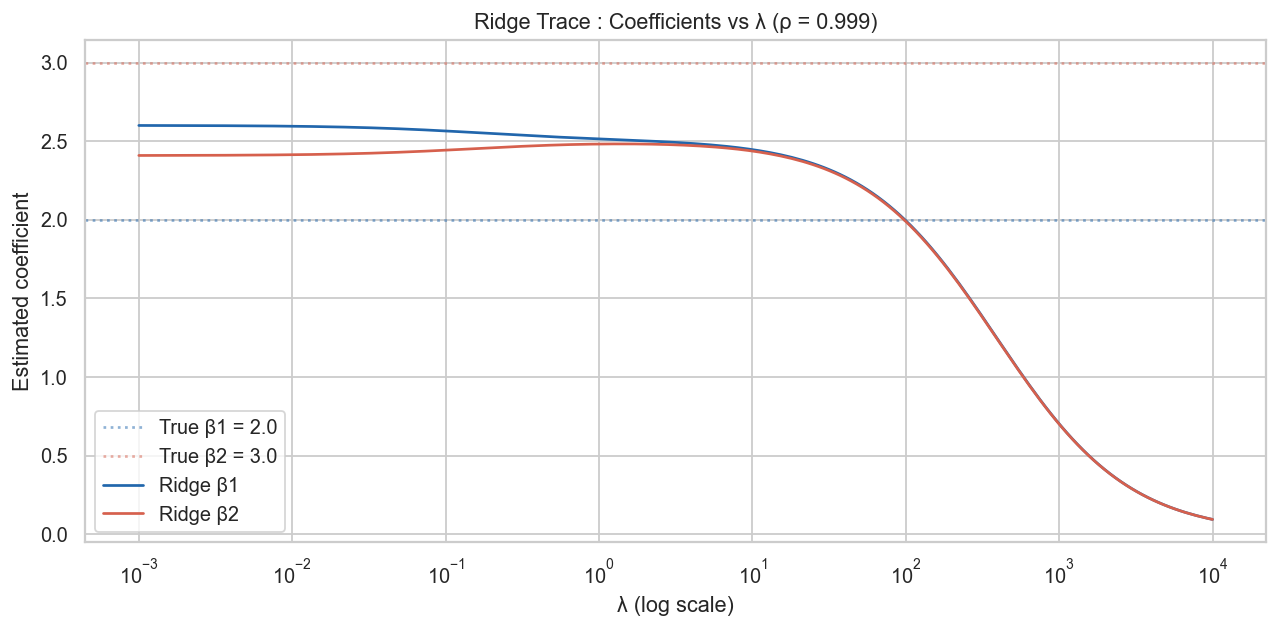

In [29]:
X_trace, y_trace, beta_true = generate_data(rho=0.999)

lambdas = np.logspace(-3, 4, 200)

beta1_path = []
beta2_path = []

for lam in lambdas:
    beta = ridge(X_trace, y_trace, lam=lam)
    beta1_path.append(beta[1])
    beta2_path.append(beta[2])

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(y=2.0, color="#2166ac", linestyle=":", alpha=0.5, label="True β1 = 2.0")
ax.axhline(y=3.0, color="#d6604d", linestyle=":", alpha=0.5, label="True β2 = 3.0")

ax.plot(lambdas, beta1_path, color="#2166ac", label="Ridge β1")
ax.plot(lambdas, beta2_path, color="#d6604d", label="Ridge β2")

ax.set_xscale("log")
ax.set_xlabel("λ (log scale)")
ax.set_ylabel("Estimated coefficient")
ax.set_title("Ridge Trace : Coefficients vs λ (ρ = 0.999)")
ax.legend()

plt.tight_layout()
plt.savefig("images/ridge_trace.png", dpi=130, bbox_inches="tight")
plt.show()

**Reading the ridge trace :**

At λ = 0, Ridge reduces to OLS. Under severe multicollinearity (ρ = 0.999),
OLS coefficients are already far from the true values (β1 = 2.0, β2 = 3.0)
and indistinguishable from each other : the matrix X'X cannot separate
the individual contributions of X1 and X2.

As λ increases, both coefficients are progressively shrunk toward zero.
The optimal λ lies in the region where the coefficients stabilize before
being over-shrunk, here around λ ∈ [0.1, 1]. Beyond λ = 10, the bias
becomes too large and both coefficients collapse toward zero.

## 7. Prediction Error : OLS vs Ridge

Stable coefficients are good, but do they actually lead to better predictions ?

We now compare the **Mean Squared Error (MSE)** of OLS and Ridge on a
held-out test set, across all values of ρ. This gives a concrete,
quantitative answer to the question : is Ridge worth the bias it introduces ?

For each value of ρ :
- We train both models on 80% of the data
- We evaluate prediction MSE on the remaining 20%
- We repeat this across all correlation levels

In [24]:
mse_results = []

for rho in rho_values:
    X, y, beta_true = generate_data(rho=rho)

    # Train/test split 80/20 en natif
    n = X.shape[0]
    n_train = int(0.8 * n)
    
    rng = np.random.default_rng(42)
    indices = rng.permutation(n)
    
    train_idx = indices[:n_train]
    test_idx  = indices[n_train:]
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit OLS and Ridge on train
    beta_ols   = ols(X_train, y_train)
    beta_ridge = ridge(X_train, y_train, lam=0.5)

    # Add intercept column to test set
    ones_test = np.ones((X_test.shape[0], 1))
    X_test_b  = np.hstack([ones_test, X_test])

    # Predictions on test set
    y_pred_ols   = X_test_b @ beta_ols
    y_pred_ridge = X_test_b @ beta_ridge

    # MSE
    mse_ols   = np.mean((y_test - y_pred_ols)  ** 2)
    mse_ridge = np.mean((y_test - y_pred_ridge) ** 2)

    mse_results.append({
        "rho"       : rho,
        "mse_ols"   : mse_ols,
        "mse_ridge" : mse_ridge,
    })

df_mse = pd.DataFrame(mse_results)

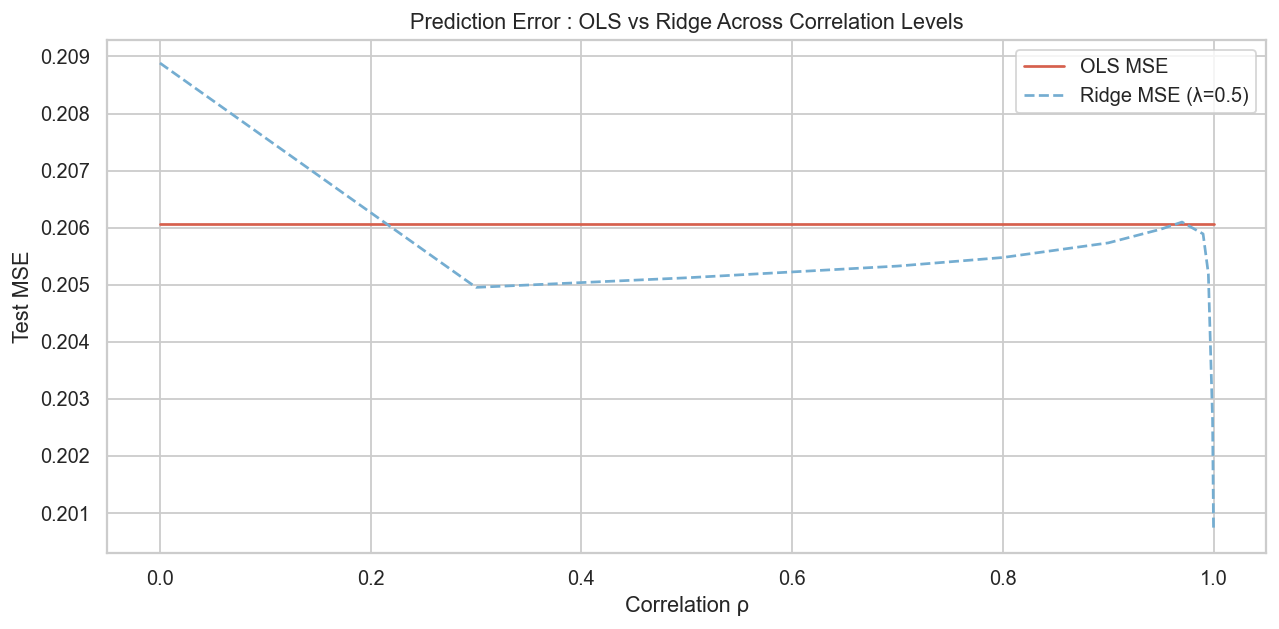

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_mse["rho"], df_mse["mse_ols"],   "-",  color="#d6604d", label="OLS MSE")
ax.plot(df_mse["rho"], df_mse["mse_ridge"], "--", color="#74add1", label="Ridge MSE (λ=0.5)")

ax.set_xlabel("Correlation ρ")
ax.set_ylabel("Test MSE")
ax.set_title("Prediction Error : OLS vs Ridge Across Correlation Levels")
ax.legend()

plt.tight_layout()
plt.savefig("images/mse_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

**Reading the results :**

An important distinction emerges here : coefficient instability does not
necessarily translate into poor prediction error.

When ρ is high, X1 and X2 carry almost identical information. Even though
OLS assigns wrong individual coefficients to each variable, the combined
prediction X @ β remains reasonable because the errors on β1 and β2
partially cancel each other out.

This explains why Ridge does not always dominate OLS on MSE : the gain
from regularization is most visible when the instability of OLS coefficients
propagates into predictions, which requires both high correlation and
sufficient noise in the data.

This is a subtle but crucial point : **a model can have unreliable
coefficients and still predict well on average**. Coefficient stability
matters most when interpretability is the goal, not just prediction.

## 8. Conclusion

This notebook demonstrated three things mathematically:

**1. OLS is fragile under multicollinearity.**
As the correlation $\rho$ between $X_1$ and $X_2$ increases, the matrix
$X^\top X$ becomes nearly singular. Its condition number $\kappa$ grows
exponentially, making the inversion numerically unstable and the
estimated coefficients unreliable.

**2. The condition number is a rigorous diagnostic.**
A condition number above 30 signals serious multicollinearity. At
$\rho = 0.999$, $\kappa$ exceeded 2000. At $\rho = 0.9999$, OLS
coefficients diverged completely from the true values.

**3. Ridge regression stabilizes the estimates.**
By adding $\lambda I$ to $X^\top X$ before inversion, Ridge shifts all
eigenvalues by $\lambda$, preventing them from reaching zero. The cost
is a small bias in the estimates, but the gain in stability is
significant under severe multicollinearity.

| | OLS | Ridge |
|---|---|---|
| Solution | Analytical | Analytical (modified) |
| Multicollinearity | Unstable | Stable |
| Bias | None | Small (controlled by λ) |
| When to use | Low correlation between features | High correlation between features |